# Conversation dynamics in podcasts: An analysis of interruptions, calls to action and sentiment across genres
This project aims to analyze conversational dynamics in podcasts using the SPORC dataset, which provides annotated podcast transcriptions with speaker and dialogue turn information. In the project, we focus on three key elements of conversational dynamics; interruptions, calls to action, and sentiment. These will be the lenses for understanding how podcast conversations differ across genres. By analyzing the existence and nature of interruptions, the use of persuasive and action oriented language toward the listeners, along with the sentiments and emotional tone, we wish to compare and characterize how conversational patterns vary between genres of podcasts. The analysis aims at sheding light on how podcasts communicate and engage audiences differently depending on their genre.

This notebook consists of an initial data exploration pipeline, and then methodological considerations for each of the parts of the analysis, which will be conducted in the P3 milestone part of this project.

## Data exploration
In this part of the notebook we have worked with loading and understanding the data to ensure the feasibility of our ideas on the actual dataset. We have calculated the descriptive statistics of the dataset at both podcast, episode and turn levels. Furthermore, we have plotted the content of the dataset and done initial interaction with the data to understand the available columns in each part of the dataset. We have used a modified version of the `sporc` library to interact with the data, and familiarized ourselves with the available functionality in here. 

### Import dependencies

In [321]:
from helpers.sporc import (
    SPORCDataset,
    get_all_categories,
    get_main_categories,
    get_main_category,
    get_subcategories_list,
    is_main_category,
    is_subcategory,
    is_valid_category,
)
from pprint import pprint
import matplotlib.pyplot as plt
from typing import Optional
import pandas as pd
import re
import re
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
from nltk import word_tokenize, pos_tag
from nltk.tokenize import sent_tokenize
from tqdm.auto import tqdm
import torch
import string
from transformers import AutoTokenizer
tqdm.pandas()
import networkx as nx
import random
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px
import numpy as np
import hdbscan
import seaborn as sns
import plotly.graph_objects as go
import statsmodels.api as sm
from sklearn.preprocessing import MultiLabelBinarizer

### Load data

I have appropriated the `sporc` library to our needs. You can load the full data from hugging face (if logged in) using 
        
    sporc = SPORCDataset()

It is also possible to use `streaming` so you wont load any data before iterating over it
    
    sporc = SPORCDataset(streaming=True)

If you have the compressed files (.gz) locally they can be read as

    sporc = SPORCDataset(local_data_dir="data")

However, since the full data is needlessly large for our purposes we will only be using the provided sample, which can be loaded as follows:

In [3]:
sporc = SPORCDataset(
    local_data_dir="data",
    load_samples_only=True,
    load_turns_eagerly=True,
    show_progress=False,
)

INFO:helpers.sporc.dataset:Loading SPORC dataset from local directory: data
INFO:helpers.sporc.dataset:Loading SPORC sample dataset only.
INFO:helpers.sporc.dataset:✓ All required files found
INFO:helpers.sporc.dataset:Loading all records from local files into memory...
INFO:helpers.sporc.dataset:Loading episode_data_sample...
INFO:helpers.sporc.dataset:Loading speaker_turn_data_sample...
INFO:helpers.sporc.dataset:✓ Loaded 210,000 total records from 2 files
INFO:helpers.sporc.dataset:✓ Local dataset loaded successfully in 10.93 seconds
INFO:helpers.sporc.dataset:✓ Dataset loaded successfully with 210000 total records
INFO:helpers.sporc.dataset:Processing dataset into Podcast and Episode objects...
INFO:helpers.sporc.dataset:Separating episode data from speaker turn data...
INFO:helpers.sporc.dataset:✓ Separation completed in 0.53 seconds
INFO:helpers.sporc.dataset:  Episode records: 10,000, Speaker turn records: 200,000
INFO:helpers.sporc.dataset:Grouping episodes by podcast...
INFO:h

In [4]:
stats = sporc.get_dataset_statistics()

print(f"Total podcasts: {stats['total_podcasts']}")
print(f"Total episodes: {stats['total_episodes']}")
print(f"Total duration: {stats['total_duration_hours']:.1f} hours")
print(f"Average episode length: {stats['avg_episode_duration_minutes']:.1f} minutes")

print("\nTop categories:")
for category, count in sorted(stats['category_distribution'].items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {category}: {count} episodes")
    
print("\nTop Languages:")
for category, count in sorted(stats['language_distribution'].items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {category}: {count} episodes")
    
print("\nTop Episode Types:")
for category, count in sorted(stats['episode_types'].items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {category}: {count} episodes")

Total podcasts: 1826
Total episodes: 10000
Total duration: 5760.4 hours
Average episode length: 34.6 minutes

Top categories:
  : 73612 episodes
  religion: 2109 episodes
  spirituality: 2106 episodes
  society: 1609 episodes
  culture: 1609 episodes

Top Languages:
  en: 7926 episodes
  en-us: 1261 episodes
  en-US: 482 episodes
  en-gb: 163 episodes
  en-au: 39 episodes

Top Episode Types:
  long_form: 4838 episodes
  short_form: 2059 episodes
  solo: 1836 episodes
  interview: 1613 episodes
  panel: 684 episodes


In [5]:
# Demonstrate category utility functions
print("Category Utility Functions:")

# Get all categories
all_categories = get_all_categories()
main_categories = get_main_categories()
subcategories = get_subcategories_list()

print(f"   Total categories: {len(all_categories)}")
print(f"   Main categories: {len(main_categories)}")
print(f"   Subcategories: {len(subcategories)}")

# Show some main categories
print(f"   Sample main categories: {main_categories[:5]}")
print(f"   Sample subcategories: {subcategories[:5]}")
print()

# Demonstrate category validation
print("Category Validation:")
test_categories = ["Education", "Astronomy", "Invalid Category", "Language Learning"]

for category in test_categories:
    is_valid = is_valid_category(category)
    is_main = is_main_category(category)
    is_sub = is_subcategory(category)

    print(f"   '{category}':")
    print(f"     Valid: {is_valid}")
    print(f"     Main category: {is_main}")
    print(f"     Subcategory: {is_sub}")

print()

Category Utility Functions:
   Total categories: 114
   Main categories: 19
   Subcategories: 95
   Sample main categories: ['Arts', 'Business', 'Comedy', 'Education', 'Fiction']
   Sample subcategories: ['After Shows', 'Alternative Health', 'Animation & Manga', 'Astronomy', 'Automotive']

Category Validation:
   'Education':
     Valid: True
     Main category: True
     Subcategory: False
   'Astronomy':
     Valid: True
     Main category: False
     Subcategory: True
   'Invalid Category':
     Valid: False
     Main category: False
     Subcategory: False
   'Language Learning':
     Valid: True
     Main category: False
     Subcategory: True



In [6]:
# Demonstrate category hierarchy & distribution 
# Note that an episode can have multiple categories
sporc.plot_category_sunburst() 

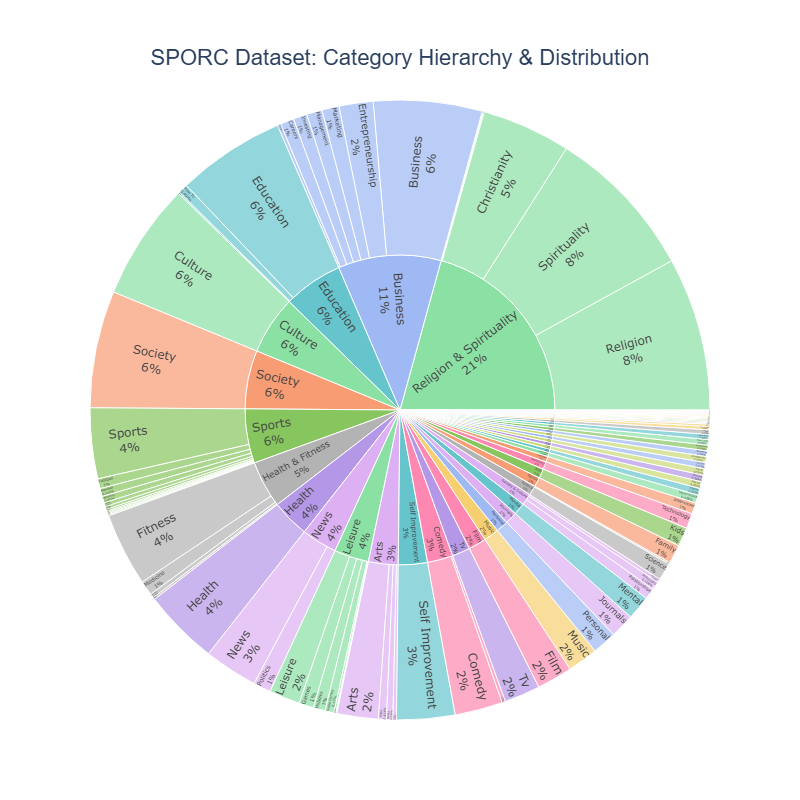

In [7]:
# Note: This plot is interactive and not visible in the rendered notebook in Github. Instead see this static image:
from IPython.display import Image
Image(filename='figures/sunburst.png') 

### Interacting with the dataset

Through `sporc` the data can be accessed through `Podcast` and `Episode` objects

In [8]:
# Accessing podcast and episode data
podcasts = sporc.get_all_podcasts() # List of Podcast objects
episodes = sporc.get_all_episodes() # List of Episode objects

print(f"Total podcasts: {len(podcasts)}")
print("Example podcast:", podcasts[0])

print(f"\nTotal episodes: {len(episodes)}")  
print("Example episode:", episodes[0])

Total podcasts: 1826
Example podcast: Podcast('SingOut SpeakOut', 5 episodes, 0.7h)

Total episodes: 10000
Example episode: Episode('Best of SingOut SpeakOut No.3', 13.4min, 1 speakers)


In [9]:
for i, podcast in enumerate(podcasts[:5]):
    print(f"[{i+1}] {podcast.title} ({len(podcast.episodes)} episodes)")

[1] SingOut SpeakOut (5 episodes)
[2] Brazen Education (2 episodes)
[3] California Community Colleges Podcast (1 episodes)
[4] Puck Bunnies (1 episodes)
[5] Anxiety 2 Confidence podcast (6 episodes)


#### Working with Podcasts

In [10]:
# searching for a podcast
podcast = sporc.search_podcast("singout speakout")

print(f"Title: {podcast.title}")
pprint(f"Description: {podcast.description}")
print(f"Number of episodes: {podcast.num_episodes}")
print(f"Total duration: {podcast.total_duration_hours:.1f} hours")
print(f"Hosts: {podcast.host_names}")
print(f"Categories: {podcast.categories}")

Title: SingOut SpeakOut
('Description: Award winning Australian singer-songwriter Simon Shapiro '
 'delivers his songs, writing and philosophy in a unique combination of idea '
 'sharing, including conversation, live performance and recorded music.')
Number of episodes: 5
Total duration: 0.7 hours
Hosts: ['Simon Shapiro']
Categories: ['', 'culture', 'education', 'music', 'philosophy', 'self improvement', 'society']


In [11]:
pprint(podcast.get_episode_statistics())

{'avg_episode_duration_minutes': 8.546666666666667,
 'category_distribution': {'': 20,
                           'culture': 5,
                           'education': 5,
                           'music': 5,
                           'philosophy': 5,
                           'self improvement': 5,
                           'society': 5},
 'date_range': {'earliest': '2020-05-17T12:00:00',
                'latest': '2020-06-20T23:00:00'},
 'episode_types': {'interview': 1,
                   'long_form': 0,
                   'panel': 0,
                   'short_form': 4,
                   'solo': 4},
 'guest_names': ['Lee Walker'],
 'host_names': ['Simon Shapiro'],
 'max_episode_duration_minutes': 13.383333333333333,
 'median_episode_duration_minutes': 7.933333333333334,
 'min_episode_duration_minutes': 6.0,
 'num_episodes': 5,
 'speaker_distribution': {1: 1, 3: 3, 4: 1},
 'total_duration_hours': 0.7122222222222222}


In [12]:
# Iterate through episodes
for episode in podcast.episodes:
    print(f"Episode: {episode.title}")
    print(f"Duration: {episode.duration_minutes:.1f} minutes")
    print(f"Date: {episode.episode_date}")
    print("---")

Episode: Quarterlife Crisis
Duration: 8.5 minutes
Date: 2020-05-17 12:00:00
---
Episode: Saturn Return
Duration: 7.9 minutes
Date: 2020-05-24 11:00:00
---
Episode: Today Is Yesterday
Duration: 6.9 minutes
Date: 2020-05-31 13:00:00
---
Episode: It's All Gone
Duration: 6.0 minutes
Date: 2020-06-14 14:00:00
---
Episode: Best of SingOut SpeakOut No.3
Duration: 13.4 minutes
Date: 2020-06-20 23:00:00
---


#### Working with Episodes

In [13]:
episode = podcast.episodes[0]

print(f"Title: {episode.title}")
pprint(f"Description: {episode.description}")
print(f"Duration: {episode.duration_minutes:.1f} minutes")
print(f"Hosts: {episode.host_names}")
print(f"Guests: {episode.guest_names}")
print(f"Categories: {episode.categories}")
print(f"Main speakers: {episode.num_main_speakers}")
pprint(f"Transcript: {episode.transcript[:300]}...")


Title: Quarterlife Crisis
('Description: <p>Big news week. The band Simon lived in the USA with, KisTone '
 'has released their debut album after 12 years of red tape. Simon runs '
 'through a brief history of the band and then introduces track 1, Quarterlife '
 'Crisis.</p>')
Duration: 8.5 minutes
Hosts: ['Simon Shapiro']
Guests: ['Lee Walker']
Categories: ['music', 'society', 'culture', 'philosophy', 'education', 'self improvement', '', '', '', '']
Main speakers: 3
("Transcript: I'm Simon Shapiro and this is Sing Out Speak Out. Here I give "
 "you the philosophies, ideas and songs I've been working on for many years "
 "but until now I've shared just too few of because I've been afraid of you "
 "and worse I've been afraid of me. My will to connect with you and share the "
 'best of me has...')


In [14]:
# Episode type flags
print(f"Is solo episode: {episode.is_solo}")
print(f"Is interview: {episode.is_interview}")
print(f"Is panel discussion: {episode.is_panel}")
print(f"Is long-form: {episode.is_long_form}")
print(f"Has guests: {episode.has_guests}")

Is solo episode: False
Is interview: True
Is panel discussion: False
Is long-form: False
Has guests: True


In [15]:
pprint(episode.get_turn_statistics())

{'avg_turn_duration': 33.97866666666666,
 'avg_words_per_turn': 47.0,
 'role_distribution': {'NO_INFERRED_ROLE': 12, 'host': 3},
 'speaker_distribution': {'SPEAKER_00': 6,
                          'SPEAKER_01': 5,
                          'SPEAKER_02': 4,
                          'SPEAKER_03': 4},
 'total_turns': 15,
 'total_words': 705}


In [16]:
# Filter by runtime
long_episodes = sporc.search_episodes(min_duration=1800) # episodes longer than 30 min
short_episodes = sporc.search_episodes(max_duration=600) # episodes shorter than 10 min

# Filter by speaker participation
solo_episodes = sporc.search_episodes(max_speakers=1)
group_episodes = sporc.search_episodes(min_speakers=3)

# Filter by host identity
episodes_by_simon = sporc.search_episodes(host_name="Simon Shapiro")

# Filter by thematic category
sport_episodes = sporc.search_episodes(category="sports")
music_episodes = sporc.search_episodes(category="music")

# Combine filters for more specific search
specefic_episodes = sporc.search_episodes(
    category="education", 
    min_speakers=2,
    min_duration=1800  
)

# Sampling examples
# Randomly sample 100 sports-related episodes
sampled_sport_episodes = sporc.search_episodes(
    category="sports",
    sampling_mode="random",
    max_episodes=100
)
# Select the first 50 long-form episodes
first_long_episodes = sporc.search_episodes(
    min_duration=1800,
    sampling_mode="first",
    max_episodes=50
)

In [17]:
episodes_by_simon # List of Episode objects

[Episode(title='Best of SingOut SpeakOut No.3', duration_seconds=803.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='It's All Gone', duration_seconds=360.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='Today Is Yesterday', duration_seconds=416.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='Saturn Return', duration_seconds=476.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='Quarterlife Crisis', duration_seconds=509.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=1)]

#### Working with Conversation Turns

In [18]:
turns = episode.get_all_turns()

print(f"Total turns: {len(turns)}", end="\n\n")

for turn in turns[:5]:
    print(f"Speaker: {turn.primary_speaker}")
    print(f"Duration: {turn.duration:.1f} seconds")
    print(f"Words: {turn.word_count}")
    print(f"Text: {turn.text[:100]}...")
    print("---")

Total turns: 15

Speaker: SPEAKER_00
Duration: 37.2 seconds
Words: 77
Text:  I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs...
---
Speaker: SPEAKER_00
Duration: 0.3 seconds
Words: 1
Text:  Hi...
---
Speaker: SPEAKER_01
Duration: 4.5 seconds
Words: 4
Text:  everyone, welcome to another...
---
Speaker: SPEAKER_01
Duration: 1.6 seconds
Words: 1
Text:  episode...
---
Speaker: SPEAKER_00
Duration: 179.6 seconds
Words: 595
Text:  of Sing Out Speak Out. Exciting news today, we have just released, I want to say we, I mean a coupl...
---


In [19]:
# Calculate basic turn statistics
durations = [turn.duration for turn in turns]
word_counts = [turn.word_count for turn in turns]

print(f"Average turn duration: {sum(durations) / len(durations):.1f} seconds")
print(f"Average words per turn: {sum(word_counts) / len(word_counts):.1f}")
print(f"Longest turn: {max(durations):.1f} seconds")
print(f"Shortest turn: {min(durations):.1f} seconds")
print(f"Total conversation time: {sum(durations) / 60:.1f} minutes")

Average turn duration: 34.0 seconds
Average words per turn: 47.0
Longest turn: 179.6 seconds
Shortest turn: 0.3 seconds
Total conversation time: 8.5 minutes


In [20]:
# Get turns from first 5 minutes
early_turns = episode.get_turns_by_time_range(0, 300)

# Get turns from last 10 minutes
late_turns = episode.get_turns_by_time_range(
    episode.duration_seconds - 600,
    episode.duration_seconds
)

# Get all turns by a specific speaker
speaker_turns = episode.get_turns_by_speaker("SPEAKER_00")

# Get all turns by host
host_turns = episode.get_host_turns()

# Get all turns by guests
guest_turns = episode.get_guest_turns()

# Get turns with at least 50 words
long_turns = episode.get_turns_by_min_length(50)

# <font color="red"> DO WE KEEP THIS HERE?</font>


> ### Problems with data
> The dataset is very detailed and straightforward to work with using the sporc library, but there are still some issues with the data to be ware of. We have found the following issues, which we will adress and think about throughout the analysis to be performed in the project:
>- Inaccuracies in the labeled speaker turns
>    - It is observed that one actual speaker turn is sometimes divided into smaller turns following each other by the same speaker, without the turn actually being broken
>    - It is also observed that podcasts without guests and only one host sometimes have turns labeled with speaker 0 and speaker 1 despite there only being one speaker
>    - Some turns metadata is also sometimes wrong, e.g. inaccurate turn duration
>    - Speaker labels are inferred using NER and heuristics, so they may be misassigned
>- Some episodes don't have any turns
>    - Despite a transscript of an episode existing there may be no turns associated with that episode, which makes some sorts of analysis impossible
>
>There might be more issues, which we have not uncovered in this initial inspection of data, but it may uncover itself during the analysis performed until P3 milestone. All of the above issues will be thought out carefully in the relation to the analysis, and will be handled and reported accordingly to be transparant about possible effects e.g. for bad turn labeling, metadata and splitting for interruption analysis, where this information is key for detection of interruptions through overlapping turns by different speakers through e.g. start and end times.
___

## Creating a usable episode set

Among the data we can load reliably, only a portion includes the `turns` object, meaning those without it have no temporal dimension. Consequently, we cannot apply our interruption analysis, which relies on this dimension. This is not entirely bad, since a smaller set works as a proof of concept for our analysis while also limiting the time needed to run costly LLMs.

Additionally, we will designate a main category to use in downstream analysis. To do this, we define a few helper functions to:
- Normalize categories to main Apple categories.
- Filter out episodes without turns, transcripts, or categories.


In [21]:
main_categories = set(main_categories)

def resolve_main_category(category):
    "Map to a known main category; return None when unrecognized."
    if not category:
        return None
    normalized = category.strip().title()
    if not normalized:
        return None
    if normalized in main_categories:
        return normalized
    mapped = get_main_category(normalized)
    if mapped in main_categories:
        return mapped
    return None


def pick_primary_category(categories):
    "Prefer recognized main categories; otherwise fall back to the first unknown label."
    main_categories_ = []
    seen = set()
    first_unrecognized = None   # no type hint needed

    for category in categories:
        resolved = resolve_main_category(category)
        if resolved and resolved not in seen:
            main_categories_.append(resolved)
            seen.add(resolved)
            continue

        if first_unrecognized is None:
            normalized = (category or "").strip().title()
            if normalized:
                first_unrecognized = normalized

    if not main_categories_ and first_unrecognized:
        main_categories_.append(first_unrecognized)

    primary = main_categories_[0] if main_categories_ else None
    return primary, main_categories_


def episode_to_record(episode):
    "Convert an Episode to a flat record if it meets our usability criteria."
    if not episode.has_turns:
        return None

    primary_main, all_main_categories = pick_primary_category(episode.categories)
    if not primary_main:
        return None

    transcript_length = len((episode.transcript or "").strip())
    if transcript_length == 0:
        return None

    return {
        "podcast_title": episode.podcast_title,
        "episode_title": episode.title,
        "duration_minutes": episode.duration_minutes,
        "turn_count": episode.turn_count,
        "main_category": primary_main,
        "all_main_categories": all_main_categories,
        "all_categories": episode.categories,
        "transcript_chars": transcript_length,
        "has_guests": episode.has_guests,
        "num_guests": episode.num_guests,
        "num_hosts": episode.num_hosts,
        "is_interview": episode.is_interview,
        "is_panel": episode.is_panel,
        "is_solo": episode.is_solo,
        "overlap_prop_duration": episode.overlap_prop_duration,
        "overlap_prop_turn_count": episode.overlap_prop_turn_count,
        "mp3_url": episode.mp3_url, # We will use this as the key
    }

### Building the pool of usable episodes
We filter out items without categories, transcripts, or turns.

In [22]:
records = []

for episode in episodes:
    record = episode_to_record(episode)
    if record:
        records.append(record)

usable_df = pd.DataFrame(records)
print(f"Usable episodes (turns > 0, transcript, main category): {len(usable_df)}")
print(f"Share with exactly one turn: {(usable_df['turn_count']==1).mean():.1%}")
usable_df.head()

Usable episodes (turns > 0, transcript, main category): 1033
Share with exactly one turn: 15.1%


,podcast_title,episode_title,duration_minutes,turn_count,main_category,all_main_categories,all_categories,transcript_chars,has_guests,num_guests,num_hosts,is_interview,is_panel,is_solo,overlap_prop_duration,overlap_prop_turn_count,mp3_url
0,SingOut SpeakOut,Best of SingOut SpeakOut No.3,13.383333,1,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",638,False,0,1,False,False,True,0.000000,0.000000,https://www.buzzsprout.com/783020/4252475-best...
1,SingOut SpeakOut,It's All Gone,6.000000,3,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",660,False,0,1,False,False,True,0.000000,0.000000,https://www.buzzsprout.com/783020/4165286-it-s...
2,SingOut SpeakOut,Today Is Yesterday,6.933333,13,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",3972,False,0,1,False,False,True,0.001847,0.153846,https://www.buzzsprout.com/783020/3983942-toda...
3,SingOut SpeakOut,Saturn Return,7.933333,12,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",3120,False,0,1,False,False,True,0.005649,0.166667,https://www.buzzsprout.com/783020/3892169-satu...
4,SingOut SpeakOut,Quarterlife Crisis,8.483333,15,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",3535,True,1,1,True,False,False,0.035983,0.266667,https://www.buzzsprout.com/783020/3791501-quar...


In [23]:
category_counts = usable_df["main_category"].value_counts().sort_values(ascending=False)
print("Category distribution in usable pool:")
display(category_counts)

Category distribution in usable pool:


main_category
Business                   165
Religion & Spirituality    163
Education                  145
Society & Culture          119
Health & Fitness           102
Sports                      69
Music                       48
Arts                        47
Comedy                      46
Leisure                     43
TV & Film                   30
News                        23
Technology                   9
Fiction                      6
True Crime                   5
Kids & Family                5
Science                      4
Government                   3
History                      1
Name: count, dtype: int64

Because episode objects are not directly serializable into a DataFrame, we store them separately while keeping them accessible for downstream interaction and analysis.

In [24]:
episode_lookup = {ep.mp3_url: ep for ep in episodes}
episodes = (usable_df['mp3_url'].map(episode_lookup)).to_list()

Finally, we save this small dataset

In [25]:
usable_df.to_parquet("data/episodes.parquet", index=False)
episodes_df = pd.read_parquet("data/episodes.parquet")

### Building the Turn-Level Dataset

Since our analysis requires operating at the level of individual turns rather than whole episodes, we construct a turn-level dataset. For each episode, we iterate through its sequence of turns, clean the text, extract relevant metadata (such as speaker, timing, and duration), and annotate properties like whether the turn was removed during cleaning or flagged as short.

The result is a flat dataframe where each row corresponds to a single turn, enabling turn-level statistics, filtering, and downstream modeling.

Before constructing this dataset, we first define a text-cleanup function that standardizes and filters turn content. This function uses a set of regular expressions to remove non-linguistic artifacts such as: `[music]` cues, stray brackets, and leading or trailing punctuation, and normalizes whitespaces. This preprocessing step ensures that the turn-level dataset contains clean, structured text suitable for both descriptive statistics and more advanced modeling.

In [26]:
MUSIC_PATTERN = re.compile( 
    r""" # Matches various forms of 'music' cues
        (\[\s*music\s*\]|\(\s*music\s*\))   
        |(\[\s*music)                       
        |(music\s*\])                       
        |^\s*music\s*$                      
    """,
    re.IGNORECASE | re.VERBOSE,
)

# Remove leftover brackets, quotes, stray punctuation clusters
#BRACKET_JUNK = re.compile(r'[\[\]\(\)]+')

def clean_turn_text(text):
    """Clean a turn's text by removing music cues, bracket noise,  
    leading punctuation, and normalizing whitespace.
    """
    if not text:
        return None

    cleaned = MUSIC_PATTERN.sub(" ", text)
    #cleaned = BRACKET_JUNK.sub(" ", cleaned)

    cleaned = cleaned.strip()
    cleaned = re.sub(r'^[\W_]+', '', cleaned) # remove leading non-alphanumerics
    cleaned = re.sub(r'[\W_]+$', '', cleaned) # remove trailing non-alphanumerics

    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    if not cleaned:
        return None

    return cleaned

In [322]:
turn_rows = []
for i, row in episodes_df.iterrows():
    ep = episodes[i]
    for j, turn in enumerate(ep.get_all_turns()):
        cleaned = clean_turn_text(turn.text)
        turn_rows.append({
            'episode_title': row['episode_title'],
            'turn_index': j,
            'speaker': ';'.join(turn.speaker) if isinstance(turn.speaker, list) else turn.speaker,
            'start_time': turn.start_time,
            'end_time': turn.end_time,
            'duration': turn.duration,
            'raw_text': turn.text,
            'clean_text': cleaned,
            'is_removed': cleaned is None,
            'num_words': len(cleaned.split()) if cleaned else 0,
            'mp3_url': row['mp3_url'],    
            'inferred_speaker_name': turn.inferred_speaker_name,
            'all_main_categories': row['all_main_categories'],     
        })
turns_df = pd.DataFrame(turn_rows)
print(f'Turn rows: {len(turns_df):,} | removed in cleaning: {turns_df["is_removed"].sum():,}')
turns_df.head()

Turn rows: 199,491 | removed in cleaning: 11,028


,episode_title,turn_index,speaker,start_time,end_time,duration,raw_text,clean_text,is_removed,num_words,mp3_url,inferred_speaker_name,all_main_categories
0,Best of SingOut SpeakOut No.3,0,SPEAKER_00,0.00,60.00,60.00,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,124,https://www.buzzsprout.com/783020/4252475-best...,Simon Shapiro,"[Music, Society & Culture, Education]"
1,It's All Gone,0,SPEAKER_00,0.00,78.16,78.16,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,172,https://www.buzzsprout.com/783020/4165286-it-s...,Simon Shapiro,"[Music, Society & Culture, Education]"
2,It's All Gone,1,SPEAKER_02,78.16,115.31,37.15,Music] [Music] [Music] [Music] [Music] [,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...,NO_INFERRED_SPEAKER,"[Music, Society & Culture, Education]"
3,It's All Gone,2,SPEAKER_01,115.31,360.16,244.85,Music] [Music] [Music] [Music] [Music] [Music]...,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...,NO_INFERRED_SPEAKER,"[Music, Society & Culture, Education]"
4,Today Is Yesterday,0,SPEAKER_05,0.00,36.99,36.99,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,77,https://www.buzzsprout.com/783020/3983942-toda...,Simon Shapiro,"[Music, Society & Culture, Education]"


**Note:** A large share of turns are very short (often fewer than a few words), indicating that the transcript quality may be limited or that many turns contain minimal linguistic content. This is important to keep in mind when interpreting downstream analyses.


In [28]:
thresholds = [2, 3, 5, 8, 10, 20, 50, 100]

# Keep only valid (non-removed) turns
valid = turns_df[~turns_df['is_removed']]['num_words']

total = len(valid)

print("Distribution of turn lengths (excluding removed turns):")
for threshold in thresholds:
    count = (valid < threshold).sum()
    pct = (count / total) * 100
    print(f"  - Turns with < {threshold:3} words: {count:7,} ({pct:5.1f}%)")

Distribution of turn lengths (excluding removed turns):
  - Turns with <   2 words:  55,287 ( 29.3%)
  - Turns with <   3 words:  74,789 ( 39.7%)
  - Turns with <   5 words:  98,017 ( 52.0%)
  - Turns with <   8 words: 113,392 ( 60.2%)
  - Turns with <  10 words: 120,089 ( 63.7%)
  - Turns with <  20 words: 140,097 ( 74.3%)
  - Turns with <  50 words: 164,376 ( 87.2%)
  - Turns with < 100 words: 177,047 ( 93.9%)


Finally, we save this turn-level dataset for future use.


In [130]:
turns_df.to_parquet("data/turns.parquet", index=False)
turns_df = pd.read_parquet("data/turns.parquet")

## Analysis & Data Enriching

### Call-to-Action Detection Pipeline

Call-to-Action (CTA) language is an important feature of persuasive communication. In marketing research, CTAs are defined as explicit prompts that encourage audiences to take a desired action, such as making a purchase or clicking on a link. Studies on digital advertising describe them as message components designed to urge consumers toward a specific behavioural response. In communication and CSR research, CTAs appear as elements that ask audiences to engage with a cause or organization, for example by donating or sharing content. From the perspective of speech-act theory, these correspond to directive speech acts where the speaker aims to influence the listener’s future actions. Because CTAs reveal how podcast hosts engage audiences, promote content or sponsors, and attempt to mobilize behaviour, detecting them is valuable for understanding the communicative and commercial structure of episodes.

> <font color="green"> Sources (not thoroughly checked): </font>  
> - [ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S1094996818300707?)  
> - [MDPI](https://www.mdpi.com/2071-1050/13/7/3812)  
> - [ResearchGate](https://doi.org/10.15294/lc.v15i1.26029)

For this project we aim to detect whether a **turn** contains at least one CTA. Although CTAs vary widely in form and purpose, we use a binary distinction for reliability and interpretability:

- **CTA**: at least one utterance encouraging the listener to perform a specific action (for example visiting a website, subscribing, donating, or following a link).  
- **Non-CTA**: no such directive.

Binary classification is appropriate because CTAs are relatively sparse and often ambiguous. Developing fine-grained categories, such as differentiating promotional CTAs from engagement or civic CTAs, would require extensive annotation guidelines and substantial training data. Given limited annotation capacity, fine-grained distinctions would be unreliable, whereas a binary label is robust and fully sufficient for downstream analyses.

CTA identification is challenging: some cases are ambiguous or context dependent, CTAs directed at co-hosts rather than listeners ideally should not be counted, and softly phrased CTAs can be difficult to detect. Whisper transcription errors may obscure key cues, and very long turns can embed CTAs among unrelated material. Despite these limitations, our pipeline aims to provide a practical and interpretable approach to identifying directive behaviour in podcast speech.

#### Detecting CTA Language

There is no established off-the-shelf method for detecting CTA language in this context. [Recent work](https://doi.org/10.48550/arXiv.2409.02690) has explored prompting large language models (LLMs) to classify persuasive or CTA-like statements directly, showing that LLMs can detect subtle directive language. In practice, CTA cues almost always appear within individual sentences, not across entire turns, and some turns in podcast transcripts are extremely long. This means that running an LLM on full turns may deteriorate detection quality and would often being infeasible due to context window limits. For this reason we will detect CTAs on sentence-level and then aggregate to the turn level. However, running an LLM on every sentence, even one of this size, is infeasible due to computational cost and time restrictions. 

To balance semantic quality and scalability, we adopt a hybrid, two-stage pipeline:

1. **Rule-based sentence-level flagging** to identify candidate CTA sentences using cheap lexical and structural cues.  
2. **LLM-based sentence-level classification** applied only to flagged sentences, followed by aggregation back to the turn level.

This design lets us use the LLM where it is most effective while avoiding the prohibitive cost of classifying all sentences.

#### Rule-Based CTA Flagging

In the first stage, we use a rule-based approach grounded in linguistic cues, lexical patterns, and URL-like expressions to flag sentences that might contain CTAs. Since no standard CTA lexicon exists for conversational speech, we developed domain-specific lexicons iteratively by:

- surveying common CTA verbs and phrases used in podcast intros, outros, and sponsor segments  
- reviewing marketing-oriented CTA verb lists (for example subscribe, follow, join, sign up, visit)  
- inspecting a sample of turns containing URLs or sponsor mentions  
- including multi-word expressions such as *"sign up"* and *"use code"* that frequently appear in spoken promotions  
- adding Whisper-style URL distortions such as *"dot com"* and *"slash slash"* to capture transcription artifacts

We then apply NLTK to split turns into sentences and use simple heuristics (CTA lexicon matches, URL-like patterns, and imperative-style structures) to flag sentences that are likely to contain CTA language. This stage is intentionally broad and inclusive: its primary goal is to capture as many potential CTAs as possible, even at the cost of false positives, so that the LLM in the next stage can focus on a much smaller subset of sentences.

The output of this step is a set of sentences marked as *candidate CTA sentences*, along with their turn indices, so that we can later aggregate back to the turn level.

In [31]:
CTA_VERBS = {
    "subscribe", "follow", "share", "like", "rate", "review",
    "visit", "check", "sign", "donate", "support", "join",
    "buy", "use", "download", "click", "call", "email",
    "register", "tell", "spread"
}

CTA_MULTIWORD = {
    "sign up", "log in", "check out"
}

CTA_PHRASES = {
    "use code", "promo code", "discount code", "free trial",
    "link in", "show notes","dot com", "dot org", "visit us at"
}

URL_PATTERN = re.compile(
    r"https?://\S+|"
    r"www\.\S+|"
    r"\b\w+\.(com|org|net|io|co)\b|"
    r"http\s+colon|"
    r"slash\s+slash",
    re.IGNORECASE
)

SECOND_PERSON = {"you", "your", "yours"}

def has_second_person(tokens):
    return any(t in SECOND_PERSON for t in tokens)


def has_cta_lexicon(tokens):
    """Return True only if a CTA verb appears in a CTA-like syntactic position."""
    if any(t in CTA_VERBS for t in tokens):
        return True
    
    return False


def is_imperative(tokens, pos_tags):
    """Very simple imperative heuristic:
    Sentence starts with a base form verb (VB) or 'please' followed by VB.
    """
    if not tokens:
        return False
    
    if pos_tags[0][1] == "VB":
        return True
    
    if tokens[0] == "please" and len(pos_tags) > 1 and pos_tags[1][1] == "VB":
        return True

    return False

In [32]:
def is_cta_sentence(sentence):
    """Return True if sentence contains CTA-like content."""
    if not isinstance(sentence, str) or not sentence.strip():
        return False

    text = sentence.lower()
    if URL_PATTERN.search(text):
        return True
    
    for phrase in CTA_PHRASES:
        if phrase in text:
            return True
        
    for phrase in CTA_MULTIWORD:
        if phrase in text:
            return True

    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    
    if is_imperative(tokens, pos_tags) and has_cta_lexicon(tokens):
        return True

    if has_cta_lexicon(tokens) and has_second_person(tokens):
        # exclude questions directed at co-hosts
        if not text.strip().endswith("?"):
            return True

    return False


def count_sentences(turn_text):
    """Count number of sentences in the turn."""
    if not isinstance(turn_text, str) or not turn_text.strip():
        return 0
    text = turn_text.strip()
    if not any(p in text for p in ".?!"):
        return 1
    return len(sent_tokenize(text))


def get_flagged_sentences(turn_text, turn_id, turn_index):
    """Return flagged CTA candidate sentences for a given turn as a list of dicts."""
    if not isinstance(turn_text, str) or not turn_text.strip():
        return []

    text = turn_text.strip()
    sentences = sent_tokenize(text) if any(p in text for p in ".?!") else [text]

    flagged = []
    for idx, s in enumerate(sentences):
        if is_cta_sentence(s):
            flagged.append({
                "sentence": s,
                "mp3_url": turn_id, 
                "turn_index": turn_index, 
                "sent_idx": idx 
            })

    return flagged


def classify_turn_cta(turn_text):
    """Return True if any sentence in the turn contains a potential CTA."""
    if not isinstance(turn_text, str) or not turn_text.strip():
        return False

    text = turn_text.strip()

    if not any(p in text for p in ".?!"):
        return is_cta_sentence(text)

    sentences = sent_tokenize(text)
    return any(is_cta_sentence(s) for s in sentences)

In [33]:
turns_df['flagged'] = turns_df['clean_text'].progress_apply(
    lambda x: classify_turn_cta(x) if isinstance(x, str) else False
)
turns_df['flagged_sentences'] = turns_df.progress_apply(
    lambda row: get_flagged_sentences(
        row['clean_text'], 
        row['mp3_url'], 
        row['turn_index']
    ) if isinstance(row['clean_text'], str) else [],
    axis=1
)

turns_df['num_flagged'] = turns_df['flagged_sentences'].apply(len)
turns_df['num_sentences'] = turns_df['clean_text'].apply(
    lambda x: count_sentences(x)
)

turns_df.head()

  0%|          | 0/199491 [00:00<?, ?it/s]

  0%|          | 0/199491 [00:00<?, ?it/s]

,episode_title,turn_index,speaker,start_time,end_time,duration,raw_text,clean_text,is_removed,num_words,mp3_url,inferred_speaker_name,flagged,flagged_sentences,num_flagged,num_sentences
0,Best of SingOut SpeakOut No.3,0,SPEAKER_00,0.00,60.00,60.00,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,124,https://www.buzzsprout.com/783020/4252475-best...,Simon Shapiro,True,[{'sentence': 'My will to connect with you and...,1,8
1,It's All Gone,0,SPEAKER_00,0.00,78.16,78.16,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,172,https://www.buzzsprout.com/783020/4165286-it-s...,Simon Shapiro,True,[{'sentence': 'My will to connect with you and...,2,9
2,It's All Gone,1,SPEAKER_02,78.16,115.31,37.15,Music] [Music] [Music] [Music] [Music] [,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...,NO_INFERRED_SPEAKER,False,[],0,0
3,It's All Gone,2,SPEAKER_01,115.31,360.16,244.85,Music] [Music] [Music] [Music] [Music] [Music]...,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...,NO_INFERRED_SPEAKER,False,[],0,0
4,Today Is Yesterday,0,SPEAKER_05,0.00,36.99,36.99,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,77,https://www.buzzsprout.com/783020/3983942-toda...,Simon Shapiro,True,[{'sentence': 'My will to connect with you and...,1,3


In [34]:
print(f"Proportion of turns flagged as CTA: {turns_df['flagged'].mean():.1%}")

valid = turns_df[turns_df['num_sentences'] > 0]
avg_cta_sentence_prop = (valid['num_flagged'] / valid['num_sentences']).mean()
print(f"Average flagged sentence proportion per turn: {avg_cta_sentence_prop:.1%}")

Proportion of turns flagged as CTA: 9.4%
Average flagged sentence proportion per turn: 4.6%


#### LLM-Based CTA Classification

In the second stage, we refine the rule-based predictions using a causal LLM. Although fine-tuning a smaller supervised classifier such as BERT or RoBERTa would likely produce the best performance, we do not have annotated data or the resources for supervised training. We therefore rely on few-shot prompting to leverage the semantic understanding of a causal LLM.

We use a few-shot prompt with representative CTA and non-CTA examples tailored to the model's expected input style to ensure consistent outputs.

The LLM is applied only to sentences flagged by the rule-based detector, which keeps computational cost manageable. Each flagged sentence receives a binary CTA label, and these sentence-level predictions are then aggregated to the turn level. A turn is considered **CTA** if at least one of its sentences is classified as containing a CTA.

In [35]:
# Create sentence level dataframe with the flagged stentences
sent_df = turns_df['flagged_sentences'].explode().dropna().to_frame()

sent_df["mp3_url"] = sent_df["flagged_sentences"].apply(lambda d: d["mp3_url"])
sent_df["turn_index"] = sent_df["flagged_sentences"].apply(lambda d: d["turn_index"])
sent_df["sentence"] = sent_df["flagged_sentences"].apply(lambda d: d["sentence"])
sent_df["sent_idx"] = sent_df["flagged_sentences"].apply(lambda d: d["sent_idx"])

sent_df = sent_df.drop(columns=['flagged_sentences'])
print(f"Number of flagged sentences: {len(sent_df):,}")
sent_df.head()

Number of flagged sentences: 29,116


,mp3_url,turn_index,sentence,sent_idx
0,https://www.buzzsprout.com/783020/4252475-best...,0,My will to connect with you and share the best...,2
1,https://www.buzzsprout.com/783020/4165286-it-s...,0,My will to connect with you and share the best...,2
1,https://www.buzzsprout.com/783020/4165286-it-s...,0,I hope you like it and I hope you have a fanta...,7
4,https://www.buzzsprout.com/783020/3983942-toda...,0,My will to connect with you and share the best...,2
7,https://www.buzzsprout.com/783020/3983942-toda...,3,But I know it can be tough when you're stuck i...,3


Podcasts often contain repetitive sections, e.g, intros, outros, and sponsor segments. Some of these parts are flagged, and we want to process them only once.

In [36]:
sent_df["sentence"][0],\
sent_df["sentence"][4]

("My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out.",
 "My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out")

In [37]:
# we normalize sentences (as a key) so punctuation and case are not distinguished.
def normalize_for_matching(s):
    if not isinstance(s, str):
        return s
    # Remove punctuation
    s2 = re.sub(f"[{re.escape(string.punctuation)}]", "", s)
    return s2.strip().lower()

sent_df["sentence_key"] = sent_df["sentence"].apply(normalize_for_matching)
sentence_counts = sent_df["sentence_key"].value_counts()

sent_df["is_repeat"] = sent_df["sentence_key"].map(lambda k: sentence_counts[k] > 1)
sent_df["num_occur"] = sent_df["sentence_key"].map(sentence_counts)
sent_df.head()

,mp3_url,turn_index,sentence,sent_idx,sentence_key,is_repeat,num_occur
0,https://www.buzzsprout.com/783020/4252475-best...,0,My will to connect with you and share the best...,2,my will to connect with you and share the best...,True,5
1,https://www.buzzsprout.com/783020/4165286-it-s...,0,My will to connect with you and share the best...,2,my will to connect with you and share the best...,True,5
1,https://www.buzzsprout.com/783020/4165286-it-s...,0,I hope you like it and I hope you have a fanta...,7,i hope you like it and i hope you have a fanta...,False,1
4,https://www.buzzsprout.com/783020/3983942-toda...,0,My will to connect with you and share the best...,2,my will to connect with you and share the best...,True,5
7,https://www.buzzsprout.com/783020/3983942-toda...,3,But I know it can be tough when you're stuck i...,3,but i know it can be tough when youre stuck in...,False,1


In [38]:
# Create df with only unique sentences
unique_sent_df = sent_df.drop_duplicates(subset=["sentence_key"]).copy()
unique_sent_df = unique_sent_df[["sentence", "sentence_key"]] # only keep needed columns

num_repeated_instances = sent_df["is_repeat"].sum()
total_instances = len(sent_df)
print(f"Repeated sentence instances: {num_repeated_instances:,} "
      f"({num_repeated_instances / total_instances:.1%})")

Repeated sentence instances: 1,853 (6.4%)


We run our CTA classifier using the **vLLM** library because it provides substantial performance and scalability benefits compared to the standard HuggingFace generation pipeline. vLLM is designed for high-throughput inference and implements an optimized attention backend (PagedAttention) that allows the model to reuse computation efficiently, especially when many prompts share the same prefix (as is the case in our few-shot classification setup). This reduces both memory usage and latency while preserving exact model behavior.

In testing, this improved inference speed by more than a factor of **15**!

Using vLLM allows us to classify a large number of sentences quickly, reliably, and at a fraction of the cost of naïve generation. This makes it practical to apply an LLM-based classifier across our full dataset without exceeding resource constraints.

We still use the HuggingFace `AutoTokenizer` to construct the prompts via its chat template. This ensures that prompts follow the exact formatting expected by the model while delegating the actual tokenization and generation to vLLM for efficient execution. 

In [39]:
MODEL_NAME = "microsoft/Phi-3-mini-128k-instruct" # 4B param model

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side='left')

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Next we design the prompt template

In [40]:
PHI3_SYSTEM_PROMPT = (
    "You are a text classification assistant. "
    "Your task is to determine whether a sentence contains a Call to Action (CTA). "
    "A CTA is any utterance encouraging the listening audience to perform a specific action. "
    "Respond ONLY with TRUE or FALSE."
)

FEW_SHOT_EXAMPLES = [
    {
        "role": "user",
        "content": "Sentence: If you enjoy this podcast, please subscribe and leave a review.\nCTA?"
    },
    {"role": "assistant", "content": "TRUE"},

    {
        "role": "user",
        "content": "Sentence: Climate change is a complex issue with many drivers.\nCTA?"
    },
    {"role": "assistant", "content": "FALSE"},

    {
        "role": "user",
        "content": "Sentence: There's a link in the show notes if you want to support the campaign.\nCTA?"
    },
    {"role": "assistant", "content": "TRUE"},

    {
        "role": "user",
        "content": "Sentence: Thanks for listening, see you next time.\nCTA?"
    },
    {"role": "assistant", "content": "FALSE"},
]

def build_fewshot_prompt(sentence):
    messages = [
        {"role": "system", "content": PHI3_SYSTEM_PROMPT},
        *FEW_SHOT_EXAMPLES,
        {
            "role": "user",
            "content": f"Sentence: {sentence}\nCTA?"
        },
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

def prompt_token_length(prompt, tokenizer):
    return len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

We build the prompts using the chat template, and ensure that we dont pass any prompts that exceed the model's context window

In [42]:
df = unique_sent_df.copy() # Shorten name to make code more readable
df["promt"] = df["sentence"].progress_apply(build_fewshot_prompt)
df["prompt_len"] = df["promt"].progress_apply(lambda p: prompt_token_length(p, tokenizer))

MAX_LEN = 4096  # Phi-3-mini limit
df["too_long"] = df["prompt_len"] > MAX_LEN
print(f"Dataframe has {df['too_long'].sum()} rows that exceed the context window")

  0%|          | 0/27976 [00:00<?, ?it/s]

  0%|          | 0/27976 [00:00<?, ?it/s]

Dataframe has 14 rows that exceed the context window


Since we are using the causal model as a classifier, we do not need natural-language fluency or varied text generation. Instead of sampling, we force deterministic behavior by selecting the most likely continuation. Concretely, we set the temperature to 0 and keep top_p = 1, ensuring the model always outputs the highest-probability token.

We run the actual model on the L4 GPU in a Google Colab Notebook

```python
# Run chunk in Colab Notebook
from vllm import LLM, SamplingParams

llm = LLM(MODEL_NAME)

params = SamplingParams(
    temperature=0.0,
    top_p=1.0,
    max_tokens=3,
)

def run_vllm(prompts, llm, params):
    outputs = llm.generate(prompts, params)
    return [o.outputs[0].text.strip() for o in outputs]

def extract_bool(text):
    t = text.strip().lower()
    if t.startswith("true"):
        return True
    if t.startswith("false"):
        return False
    return None
```

```python
# Run chunk in Colab Notebook
valid_df = df[~df["too_long"]].copy()

prompts = valid_df["promt"].tolist()
llm_outputs = run_vllm(prompts, llm, params)
valid_df["llm_out"] = llm_outputs
valid_df["has_cta"] = valid_df["llm_out"].apply(extract_bool)

# Insert predictions back into full df
df.loc[~df["too_long"], "llm_out"] = valid_df["llm_out"]
df.loc[~df["too_long"], "has_cta"] = valid_df["has_cta"]

# Long prompts get default
df.loc[df["too_long"], "llm_out"] = None
df.loc[df["too_long"], "has_cta"] = None 

df.to_parquet("data/sentences_llm.parquet", index=False)
```

In [44]:
df = pd.read_parquet("data/sentences_llm.parquet")
df.head()

,sentence,sentence_key,promt,prompt_len,too_long,llm_out,has_cta
0,My will to connect with you and share the best...,my will to connect with you and share the best...,<|system|>\nYou are a text classification assi...,197,False,FALSE,False
1,I hope you like it and I hope you have a fanta...,i hope you like it and i hope you have a fanta...,<|system|>\nYou are a text classification assi...,178,False,FALSE,False
2,But I know it can be tough when you're stuck i...,but i know it can be tough when youre stuck in...,<|system|>\nYou are a text classification assi...,244,False,FALSE,False
3,"If you like the song, it's available at all th...",if you like the song its available at all the ...,<|system|>\nYou are a text classification assi...,297,False,TRUE,True
4,If you like the,if you like the,<|system|>\nYou are a text classification assi...,167,False,FALSE,False


In [45]:
# Aggregate back to duplicate sentences
sent_df = sent_df.merge(
    df[["sentence_key", "has_cta"]],
    on="sentence_key",
    how="left"
)
sent_df.to_parquet("data/sentences.parquet", index=False)

total = len(sent_df)
num_true = (sent_df["has_cta"] == True).sum()
num_none = sent_df["has_cta"].isna().sum()

pct_true = num_true / total * 100
pct_none = num_none / total * 100

print(
    f"CTA Detection Summary\n"
    f"---------------------\n"
    f"Total flagged sentences: {total:,}\n"
    f"CTA detected (True): {num_true:,} ({pct_true:.2f}%)\n"
    f"Unparsed model outputs (None): {num_none} ({pct_none:.2f}%)\n"
)

CTA Detection Summary
---------------------
Total flagged sentences: 29,116
CTA detected (True): 3,803 (13.06%)
Unparsed model outputs (None): 21 (0.07%)



##### Aggregating back to `turns_df`

In [46]:
# Check whether each turn contains any CTA sentences
turn_llm_cta = (
    sent_df
    .groupby(["mp3_url", "turn_index"])["has_cta"]
    .any()
    .rename("has_cta")
)

turns_df = (
    turns_df
    .merge(turn_llm_cta, on=["mp3_url", "turn_index"], how="left")
    .assign(
        # Any turns that were not flagged are marked as Non-CTA
        has_cta=lambda df: df["has_cta"].fillna(False).astype(bool)
    )
)

# Collect CTA sentences per turn
cta_sentences = (
    sent_df.loc[sent_df["has_cta"] == True]
    .groupby(["mp3_url", "turn_index"])["sentence"]
    .apply(list)
    .rename("cta_sentences")
    .reset_index()
)

cta_sentences["num_cta_sentences"] = cta_sentences["cta_sentences"].str.len()

turns_df = (
    turns_df
    .merge(cta_sentences, on=["mp3_url", "turn_index"], how="left")
    .assign(
        # Fill NA values with appropriate defaults
        cta_sentences=lambda df: df["cta_sentences"].where(
            df["cta_sentences"].notna(), None
        ),
        num_cta_sentences=lambda df: df["num_cta_sentences"]
            .fillna(0)
            .astype("Int64")
    )
)

turns_df.head()

/var/folders/67/2scq7zz10y9gh4cp287_n66h0000gn/T/ipykernel_42252/1225468026.py:14: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,episode_title,turn_index,speaker,start_time,end_time,duration,raw_text,clean_text,is_removed,num_words,mp3_url,inferred_speaker_name,flagged,flagged_sentences,num_flagged,num_sentences,has_cta,cta_sentences,num_cta_sentences
0,Best of SingOut SpeakOut No.3,0,SPEAKER_00,0.00,60.00,60.00,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,124,https://www.buzzsprout.com/783020/4252475-best...,Simon Shapiro,True,[{'sentence': 'My will to connect with you and...,1,8,False,None,0
1,It's All Gone,0,SPEAKER_00,0.00,78.16,78.16,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,172,https://www.buzzsprout.com/783020/4165286-it-s...,Simon Shapiro,True,[{'sentence': 'My will to connect with you and...,2,9,False,None,0
2,It's All Gone,1,SPEAKER_02,78.16,115.31,37.15,Music] [Music] [Music] [Music] [Music] [,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...,NO_INFERRED_SPEAKER,False,[],0,0,False,None,0
3,It's All Gone,2,SPEAKER_01,115.31,360.16,244.85,Music] [Music] [Music] [Music] [Music] [Music]...,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...,NO_INFERRED_SPEAKER,False,[],0,0,False,None,0
4,Today Is Yesterday,0,SPEAKER_05,0.00,36.99,36.99,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,77,https://www.buzzsprout.com/783020/3983942-toda...,Simon Shapiro,True,[{'sentence': 'My will to connect with you and...,1,3,False,None,0


In [47]:
print(f"Proportion of turns with a CTA: {turns_df['has_cta'].mean():.1%}")

valid = turns_df[turns_df['num_sentences'] > 0]
avg_cta_sentence_prop = (valid['num_cta_sentences'] / valid['num_sentences']).mean()
print(f"Average CTA sentence proportion per turn: {avg_cta_sentence_prop:.1%}")

Proportion of turns with a CTA: 1.3%
Average CTA sentence proportion per turn: 0.4%


These results make sense for this type of data. Only about 1.3% of turns include a CTA, which fits the expected structure of most podcasts where CTAs mainly show up in intros, outros, or sponsor reads rather than in regular conversation. The average CTA-sentence share of 0.4% also seems reasonable, since a turn that contains a CTA usually includes just a single directive sentence. Most turns are purely conversational, so the low frequency is what we would expect.

_____

### Sentiment Analysis
1. Use existing lexicons of sentiments e.g. VADER, nrc, AFINN, Bing (combination of emotions and categorical/numeric scores)
2. HuggingFace fine-tuned transformer 
3. Other approaches?

Try to run the different methods on the data and do proxy evaluations with no ground truth by:
- Comparing inter-method agreement on sentiments and polarity
- Do a sanity check of a sample
- Pull samples with highest and lowest confidence and check for "traps" giving wrong labels or "shortcuts" to the right label
- Check which words are often found togehter with negations like not, cant etc., to see if that could influence the results + do an actual flip test by testing statements and the same statement prefixed with not to compare sentiments and scores (robustness)

When choosing a method also run an evaluation on a known emotion/sentiment benchmark to make sure performance there is also reasonable as an additonal sanity check.

When landing on an approach the analysis should consist of sentiment analysis and descriptive overviews and comparisons as well as time series overview of sentiment over an episode length. Both should be supported by nice visualizations to tell the story of the use of emotions and polarity in the podcasts across each genre. Inspired to some degree by this report: https://www.kaggle.com/code/josephnehrenz/nlp-sentiment-analysis-of-joe-rogan-experience/report but with added elements. 

---

### Interruptions analysis

Diving into the analysis of interruptions, might unravel hidden patterns and relationships between the different genres and conversational dynamics, which could be interesting to explore. The analysis will be carried out in the following steps:

#### 1. Detection Pipeline:
- Use the explicit appoach of doing speech overlap detection based on time-aligned speaker diarization data to detect interruptions
- Apply acoustic feature analysis (e.g., changes in energy, pitch, or pause duration) to refine detection and distinguish genuine interruptions from non-interruptions
- Look into alternative machine-learning based approaches for more flexible interruption detection

#### 2. Feature extraction:
- Extract features such as interruption duration, speaker roles (initiator vs. target), position within a turn, and other relevant information
- Compute aggregate metrics like interruption frequency per speaker, average overlap ratio, and turn transition latency 

#### 3. Unsupervised clustering:
- Apply unsupervised clustering (e.g., k-means, DBSCAN or more advanced algorithms) to group interruptions by shared characteristics (e.g., cooperative overlaps vs. competitive interruptions)
- Compare resulting clusters across genres or speaker groups to identify stylistic or contextual differences

#### 4. Genre level comparison:
- Conduct comparative analyses across genres (e.g., interviews, debates, casual discussions) based on interruption type, frequency, and overlap characteristics.  
- Create visual summaries such as heatmaps or timeline plots to illustrate conversational flow and interruption density
- Highlight findings related to social dynamics, power relations, and collaboration patterns inferred from interruption behavior

In [324]:
isInterruption = []
interruptions = []        
interruptions_per_episode = []  
categories_per_episode = []   
episode_id = []
turns_for_sentiment = []
interruption_dynamics = []

# Keep track of previous turn info
prev_end = None
prev_speaker = None
prev_episode_title = None
prev_clean_text = None
prev_inferred_speaker = None

episode_counts = {}
episode_categories = {}  

for turn in turns_df.itertuples():
    if prev_end is None:
        isInterruption.append(False)
    else:
        same_episode = (turn.episode_title == prev_episode_title)
        prev_has_text = pd.notnull(prev_clean_text) and str(prev_clean_text).strip() != ""
        cur_has_text = pd.notnull(turn.clean_text) and str(turn.clean_text).strip() != ""
        overlap = turn.start_time < prev_end
        different_speaker = turn.speaker != prev_speaker
        interrupted = same_episode and prev_has_text and cur_has_text and overlap and different_speaker
        isInterruption.append(interrupted)

        if interrupted:
            interruptions.append(turn.clean_text)
            turns_for_sentiment.append((turn.episode_title, turn.turn_index))
            ep_row = episodes_df[episodes_df.episode_title == turn.episode_title]
            episode_counts[turn.episode_title] = episode_counts.get(turn.episode_title, 0) + 1
            episode_id.append(ep_row.index[0])
            if not ep_row.empty:
                episode_categories[turn.episode_title] = list(ep_row.iloc[0].all_main_categories)
            else:
                episode_categories[turn.episode_title] = []

            if (prev_inferred_speaker is not None and prev_inferred_speaker != 'NO_INFERRED_SPEAKER' and
                turn.inferred_speaker_name is not None and turn.inferred_speaker_name != 'NO_INFERRED_SPEAKER' and
                prev_inferred_speaker != turn.inferred_speaker_name):
                interruption_dynamics.append({
                    "interrupter": turn.inferred_speaker_name,
                    "interrupted": prev_inferred_speaker,
                })

    # Update previous turn info
    prev_end = turn.end_time
    prev_speaker = turn.speaker
    prev_episode_title = turn.episode_title
    prev_clean_text = turn.clean_text
    prev_inferred_speaker = turn.inferred_speaker_name

turns_df["isInterruption"] = isInterruption
for ep in turns_df["episode_title"].unique():
    interruptions_per_episode.append(episode_counts.get(ep, 0))
    categories_per_episode.append(episode_categories.get(ep, []))

print("Total interruptions found:", sum(isInterruption))



Total interruptions found: 206


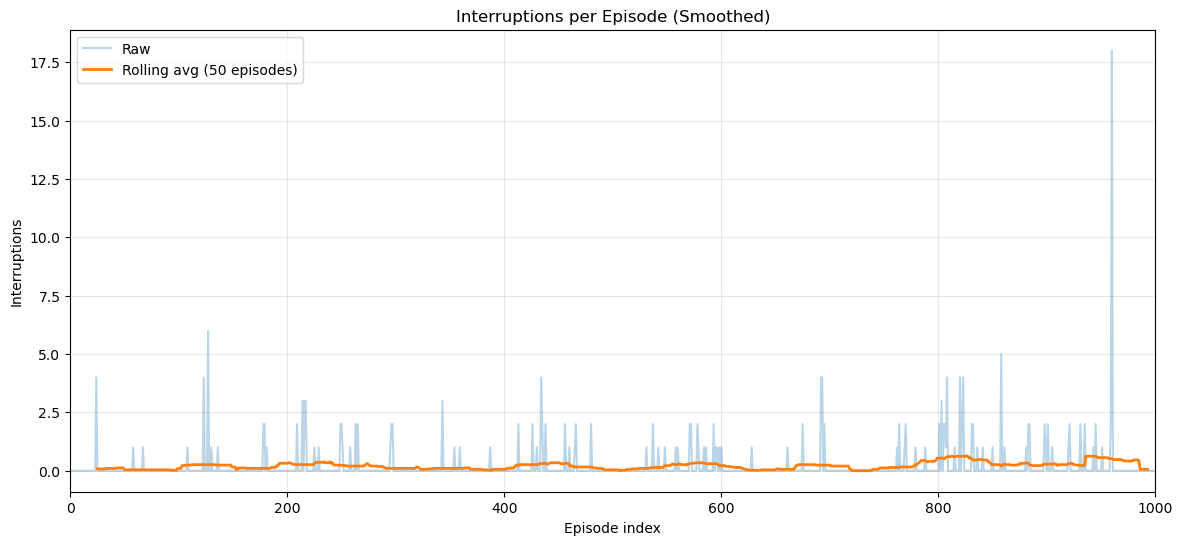

In [268]:
#plot of interruptions per episode
s = pd.Series(interruptions_per_episode)
rolling = s.rolling(window=50, center=True).mean()

plt.figure(figsize=(14, 6))
plt.plot(s, alpha=0.3, label="Raw")
plt.plot(rolling, linewidth=2, label="Rolling avg (50 episodes)")

plt.title("Interruptions per Episode (Smoothed)")
plt.xlabel("Episode index")
plt.ylabel("Interruptions")
plt.xlim(0, 1000)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


===== Average Interruptions per Category =====


,avg_interruptions
categories,
News,3.333333
Sports,2.714286
Music,2.666667
Health & Fitness,2.400000
Leisure,2.375000
Science,2.200000
Comedy,1.840000
Education,1.777778
TV & Film,1.571429



===== Total Interruptions per Category =====


,total_interruptions
categories,
Sports,57
Comedy,46
Education,32
Health & Fitness,24
Leisure,19
Music,16
Society & Culture,16
Business,14
Arts,12



===== Number of Episodes per Category =====


,episode_count
categories,
Comedy,25
Sports,21
Education,18
Society & Culture,11
Business,11
Health & Fitness,10
Arts,8
Leisure,8
TV & Film,7


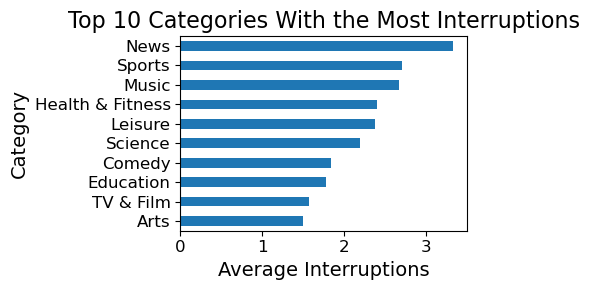

In [269]:
#Interruption across categories analysis
df = pd.DataFrame({
    "episode": list(range(len(categories_per_episode))),
    "categories": categories_per_episode,
    "interruptions": interruptions_per_episode
})

# Explode categories into separate rows
df_exploded = df.explode("categories")
df_exploded = df_exploded[df_exploded["categories"].str.strip() != ""]

print("\n===== Average Interruptions per Category =====")
category_mean = df_exploded.groupby("categories")["interruptions"].mean().sort_values(ascending=False)
display(category_mean.to_frame(name="avg_interruptions").head(10))

print("\n===== Total Interruptions per Category =====")
category_sum = df_exploded.groupby("categories")["interruptions"].sum().sort_values(ascending=False)
display(category_sum.to_frame(name="total_interruptions").head(10))

print("\n===== Number of Episodes per Category =====")
category_counts = df_exploded["categories"].value_counts()

display(category_counts.to_frame(name="episode_count").head(10))

# Select top 10
top_10 = category_mean.head(10)
# Plot
plt.figure(figsize=(5, 3))
top_10.sort_values().plot(kind="barh", fontsize=12)
plt.title("Top 10 Categories With the Most Interruptions", fontsize=16)
plt.xlabel("Average Interruptions", fontsize=14)
plt.ylabel("Category", fontsize=14)
plt.tight_layout()
plt.show()


===== All Interrupters =====


,interrupter,count,pct_of_all
0,Scott Phillips,1,100.0


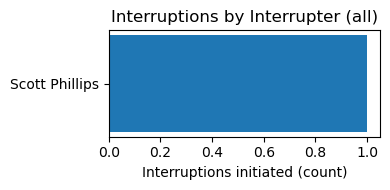

In [270]:
# find the top interrupters and interrupted
df = pd.DataFrame(interruption_dynamics)

edges = (
  df.groupby(["interrupter", "interrupted"])
    .size()
    .reset_index(name="count")
)

outgoing = edges.groupby("interrupter")["count"].sum().sort_values(ascending=False)
top_interrupters = set(outgoing.index)
# Nicely display top interrupters (replace the simple pprint dump)
# Show all interrupters
df_all = outgoing.reset_index()
df_all.columns = ["interrupter", "count"]
total_outgoing = df_all["count"].sum()
df_all["pct_of_all"] = df_all["count"] / total_outgoing * 100

print("\n===== All Interrupters =====")
display(df_all)

# Horizontal bar plot for all interrupters (sorted)
df_plot = df_all.sort_values("count")
plt.figure(figsize=(4, 2))
plt.barh(df_plot["interrupter"], df_plot["count"], color="C0")
plt.xlabel("Interruptions initiated (count)")
plt.title("Interruptions by Interrupter (all)")
plt.tight_layout()
plt.show()


In [271]:
#create interruption graph
G = nx.DiGraph()
for row in edges.itertuples():
    G.add_edge(row.interrupter, row.interrupted, weight=row.count)

pos = nx.spring_layout(G, k=0.5, seed=48)
nx.set_node_attributes(G, pos, 'pos')

edge_traces = []
for u, v, d in G.edges(data=True):
    x0, y0 = G.nodes[u]['pos']
    x1, y1 = G.nodes[v]['pos']
    edge_width = d['weight'] * 0.1  
    edge_trace = go.Scatter(
        x=[x0, x1],
        y=[y0, y1],
        line=dict(width=edge_width, color='#888'),
        hoverinfo='text',
        mode='lines'
    )
    edge_traces.append(edge_trace)

node_x = []
node_y = []
for node in G.nodes():
    x, y = G.nodes[node]['pos']
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',         
    text=[node for node in G.nodes()],  
    textposition='top center',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        reversescale=True,
        color=[],
        size=30,
        colorbar=dict(
            thickness=15,
            title=dict(
                text='Node Connections',
                side='right'
            ),
            xanchor='left',
        ),
        line_width=2
    )
)

node_adjacencies = []
node_text = []

for node, adjacencies in G.adjacency():
    node_adjacencies.append(len(adjacencies))  
    node_text.append(f'{node}<br># of connections: {len(adjacencies)}')

node_trace.marker.color = node_adjacencies
node_trace.text = [node for node in G.nodes()]  
node_trace.hovertext = node_text                
fig = go.Figure(data=edge_traces + [node_trace],
                layout=go.Layout(
                    title=dict(
                        text="Podcast Interruption Network",
                        font=dict(size=16)
                    ),
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20,l=5,r=5,t=40),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
               )

fig.show()



In [272]:
#sentence embeddings
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = model.encode(interruptions)
print(embeddings.shape)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

(206, 384)


In [273]:
pca = PCA(n_components=10, random_state=42) #reduce embedding dimensions before clustering
reduced_embeddings = pca.fit_transform(embeddings)
def evaluate_k_range(X, k_min=3, k_max=15):
    scores = {}
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores[k] = score
    return scores

scores = evaluate_k_range(reduced_embeddings)
k = max(scores, key=scores.get) #pick highest silhouette score
print(f"Chosen k = {k} with silhouette score = {scores[k]:.4f}")
print("")
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(reduced_embeddings)
for text, label in zip(interruptions[:10], kmeans_labels[:10]):
    print(f"[Cluster {label}] {text}")


Chosen k = 3 with silhouette score = 0.2201

[Cluster 1] failed it at schoolcraft, failed it once at Eastern, and then, uh, who got, I think I, uh, I won, like, had to do a placement test and I, uh, completed the placement test by one point and each question was worth seven points, so God knows how I did that. And then, uh, I took an online class so I could cheat, because I knew I wasn't going to pass it. Yeah, you got a, you got a cheat. Yeah, I took the baby, baby math in college. Like, the final project was like writing a yearly budget. [laughter] He's not like the starting salary for your career. It was so easy. It was like trash math, but like, it counted. Um, yeah, if you fail it three times, that's, that's, that's when it becomes a hobby. Yeah, that point skateboarding is just a hobby. [laughter] Yeah, what we were saying earlier is skateboarding is a way to express myself. Okay. Dan, Dan, Kev, yelling at it. Dad, this is how I express myself. Yeah. I throw myself at concrete fo

In [274]:
#interpret cluster centers
cluster_centers = kmeans.cluster_centers_
for c in range(k):
    print(f"\nCluster {c} examples:")
    cluster_members = np.where(kmeans_labels == c)[0][:1] # show 1 examples per cluster
    for i in cluster_members[:10]:
        print("  ", interruptions[i])


Cluster 0 examples:
   Don

Cluster 1 examples:
   failed it at schoolcraft, failed it once at Eastern, and then, uh, who got, I think I, uh, I won, like, had to do a placement test and I, uh, completed the placement test by one point and each question was worth seven points, so God knows how I did that. And then, uh, I took an online class so I could cheat, because I knew I wasn't going to pass it. Yeah, you got a, you got a cheat. Yeah, I took the baby, baby math in college. Like, the final project was like writing a yearly budget. [laughter] He's not like the starting salary for your career. It was so easy. It was like trash math, but like, it counted. Um, yeah, if you fail it three times, that's, that's, that's when it becomes a hobby. Yeah, that point skateboarding is just a hobby. [laughter] Yeah, what we were saying earlier is skateboarding is a way to express myself. Okay. Dan, Dan, Kev, yelling at it. Dad, this is how I express myself. Yeah. I throw myself at concrete for sev

In [275]:
#t-SNE visualization of clusters
def plot_clustering(embeddings, labels, dims=2, texts=None, perplexity=30, random_state=42):
    """
    Visualizes sentence clusters using t-SNE in 2D or 3D.

    Parameters:
    - embeddings: numpy array of shape (n_samples, n_features)
    - labels: list or array of cluster labels
    - dims: 2 or 3 (number of t-SNE output dimensions)
    - texts: optional list of sentences (used only for 3D tooltips)
    - perplexity: t-SNE perplexity
    - random_state: random seed for reproducibility
    """

    if dims not in [2, 3]:
        raise ValueError("dims must be 2 or 3.")

    tsne = TSNE(
        n_components=dims,
        perplexity=perplexity,
        random_state=random_state
    )

    projections = tsne.fit_transform(embeddings)

    # ---------------------- 2D PLOT ----------------------
    if dims == 2:
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(
            projections[:, 0],
            projections[:, 1],
            c=labels,
            s=50,
            alpha=0.8
        )
        plt.title("t-SNE Clustering (2D)")
        plt.xlabel("TSNE-1")
        plt.ylabel("TSNE-2")
        plt.show()

    # ---------------------- 3D PLOT ----------------------
    else:
        if texts is None:
            texts = [""] * len(labels)

        df_plot = pd.DataFrame({
            "x": projections[:, 0],
            "y": projections[:, 1],
            "z": projections[:, 2],
            "cluster": labels,
            "text": texts
        })

        fig = px.scatter_3d(
            df_plot, 
            x='x', y='y', z='z',
            color='cluster',
            hover_name='text',
            labels={'color': 'cluster'}
        )
        fig.update_traces(marker_size=4)
        fig.update_layout(title="t-SNE Clustering (3D)")
        fig.show()

In [276]:
plot_clustering(reduced_embeddings, kmeans_labels, dims=3, texts=interruptions)

In [277]:
# DBSCAN clustering
clusterer = hdbscan.HDBSCAN(
    
)
dbscan_labels = clusterer.fit_predict(reduced_embeddings)

def evaluate_dbscan(X, labels, clusterer=None):
    print("\n========== DBSCAN / HDBSCAN Evaluation ==========\n")

    # -------------------------------
    # Basic Stats
    # -------------------------------
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    print(f"Clusters found (excluding noise): {n_clusters}")
    print(f"Noise ratio: {noise_ratio:.3f}")

    # -------------------------------
    # Silhouette (excluding noise)
    # -------------------------------
    mask = labels != -1
    if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
        print(f"Silhouette score (no noise): {sil:.4f}")
    else:
        print("Silhouette score: Not enough clusters (need ≥2).")

    # -------------------------------
    # HDBSCAN-specific metrics
    # -------------------------------
    if clusterer is not None and hasattr(clusterer, "cluster_persistence_"):

        persistence = clusterer.cluster_persistence_
        print("\n--- HDBSCAN Cluster Stability Scores ---")

        # Case 1 — dict
        if isinstance(persistence, dict):
            for cid, stability in persistence.items():
                print(f"Cluster {cid}: stability = {stability:.2f}")

        # Case 2 — structured array (has dtype names)
        elif isinstance(persistence, np.ndarray) and persistence.dtype.names is not None:
            # structured array fields may be ('cluster', 'persistence')
            cid_field = persistence.dtype.names[0]
            stab_field = persistence.dtype.names[1]
            for row in persistence:
                print(f"Cluster {row[cid_field]}: stability = {row[stab_field]:.2f}")

        # Case 3 — plain 1D numpy array (stability only)
        elif isinstance(persistence, np.ndarray) and persistence.dtype.names is None:
            for i, stability in enumerate(persistence):
                print(f"Cluster {i}: stability = {stability:.2f}")

        else:
            print("Unknown cluster_persistence_ format.")


        # ---- Outlier scores ----
        if hasattr(clusterer, "outlier_scores_"):
            print("\n--- HDBSCAN Outlier Analysis ---")
            print(f"Mean outlier score: {np.mean(clusterer.outlier_scores_):.4f}")

    print("\n=================================================\n")

    
evaluate_dbscan(reduced_embeddings, dbscan_labels, clusterer=clusterer)


========== DBSCAN / HDBSCAN Evaluation ==========

Clusters found (excluding noise): 2
Noise ratio: 0.383
Silhouette score (no noise): 0.2305

--- HDBSCAN Cluster Stability Scores ---
Cluster 0: stability = 0.03
Cluster 1: stability = 0.09

--- HDBSCAN Outlier Analysis ---
Mean outlier score: 0.0978




/Users/mikkel/miniconda3/envs/exam/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/mikkel/miniconda3/envs/exam/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [278]:
plot_clustering(reduced_embeddings, dbscan_labels, dims=3, texts=interruptions)

category,Arts,Business,Comedy,Education,Fiction,Health & Fitness,Leisure,Music,News,Religion & Spirituality,Science,Sports,TV & Film,Technology,Total Interruptions
kmeans_cluster,,,,,,,,,,,,,,,
0,2,0,3,1,0,1,0,1,2,0,1,4,0,0,15
1,1,3,3,2,1,2,3,1,1,1,1,8,1,1,29
2,0,0,3,0,0,0,0,0,4,0,0,2,0,0,9


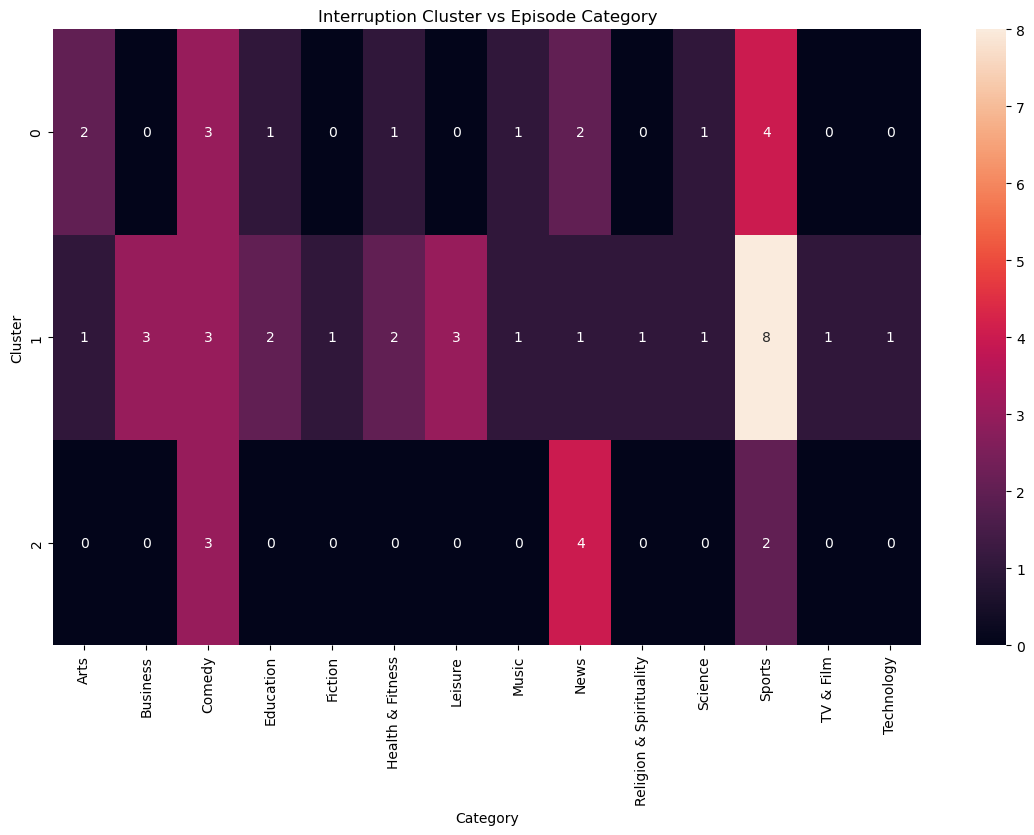

In [292]:
df = pd.DataFrame({
    "kmeans_cluster": kmeans_labels,
    "dbscan_cluster": dbscan_labels,
    "episode_id": episode_id,
})

# Convert categories_per_episode list to a dictionary for mapping
episode_to_categories = {i: categories_per_episode[i] for i in range(len(categories_per_episode))}
df["category"] = df["episode_id"].map(episode_to_categories)

# Since each episode has multiple categories, explode the category column
df = df.explode("category")
df = df[df["category"].str.strip() != ""]
table = pd.crosstab(df["kmeans_cluster"], df["category"])
#add total number of interruptions per cluster
table["Total Interruptions"] = table.sum(axis=1)
display(table)

plt.figure(figsize=(14, 8))
#should print before total interruptions
sns.heatmap(table.drop(columns=["Total Interruptions"]), annot=True, fmt="d")
plt.title("Interruption Cluster vs Episode Category")
plt.xlabel("Category")
plt.ylabel("Cluster")
plt.show()

### Correlation Analysis

In [294]:
def get_interruption_window(episode_title, turn_index, k):

    episode_turns = (
        turns_df[turns_df["episode_title"] == episode_title]
        .sort_values("turn_index")
        .reset_index(drop=True)
    )

    matches = episode_turns.index[episode_turns["turn_index"] == turn_index]

    if len(matches) == 0:
        raise ValueError(f"Turn index {turn_index} not found in episode {episode_title}")

    row_idx = matches[0]

    rows = []

    # Compute window bounds
    start_idx = max(0, row_idx - k)
    end_idx = min(len(episode_turns) - 1, row_idx + k)
    for idx2 in range(start_idx, end_idx + 1):
        turn = episode_turns.iloc[idx2]

        offset = idx2 - row_idx  

        rows.append({
            "episode_title": episode_title,
            "anchor_turn_index": turn_index,
            "target_turn_index": int(turn.turn_index),
            "offset": offset,
            "speaker": turn.speaker,
            "text": turn.clean_text,
            "start_time": turn.start_time,
            "end_time": turn.end_time,
            "duration": turn.duration,
        })

    return rows


In [296]:
#can be used for sentiment analysis before/after an interruption
for turn in turns_for_sentiment[:2]:
    window = get_interruption_window(
    episode_title=turn[0],
    turn_index=turn[1],
    k=3
    )
    for row in window:
        print(row["offset"], row["speaker"], ":", row["text"])
    print("")

-3 SPEAKER_02;SPEAKER_04 : Yeah, N
-2 SPEAKER_04 : olly K-bomb. Yeah, Nolly K-bomb
-1 SPEAKER_04;SPEAKER_02 : Yeah, Nolly K-bomb
0 SPEAKER_02 : failed it at schoolcraft, failed it once at Eastern, and then, uh, who got, I think I, uh, I won, like, had to do a placement test and I, uh, completed the placement test by one point and each question was worth seven points, so God knows how I did that. And then, uh, I took an online class so I could cheat, because I knew I wasn't going to pass it. Yeah, you got a, you got a cheat. Yeah, I took the baby, baby math in college. Like, the final project was like writing a yearly budget. [laughter] He's not like the starting salary for your career. It was so easy. It was like trash math, but like, it counted. Um, yeah, if you fail it three times, that's, that's, that's when it becomes a hobby. Yeah, that point skateboarding is just a hobby. [laughter] Yeah, what we were saying earlier is skateboarding is a way to express myself. Okay. Dan, Dan, Kev

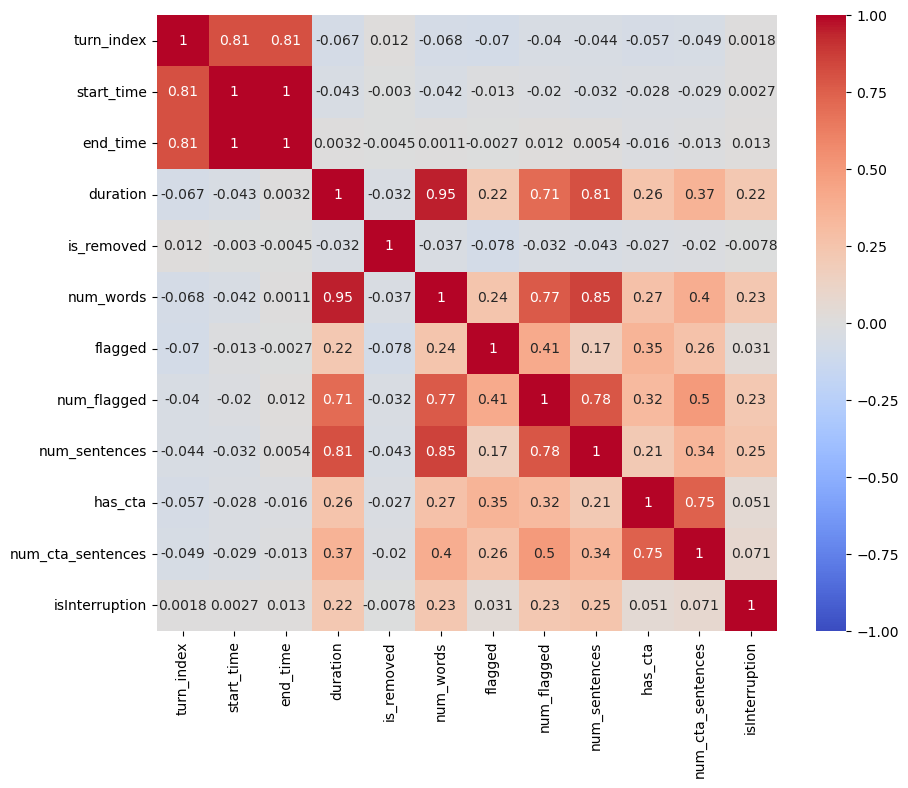

In [311]:
corr = turns_df.corr(numeric_only=True) #correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

In [304]:
#correlation for a specific variable
turns_df.corr(numeric_only=True)['isInterruption'].sort_values(ascending=False)

isInterruption       1.000000
num_sentences        0.247511
num_words            0.232845
num_flagged          0.226064
duration             0.224541
num_cta_sentences    0.071303
has_cta              0.050775
flagged              0.031429
end_time             0.012958
start_time           0.002677
turn_index           0.001792
is_removed          -0.007777
Name: isInterruption, dtype: float64

In [ ]:
#predict if a turn is an interruption or not from its duration, number of words and turn index
X = turns_df[['turn_index', 'duration', 'num_words']]
y = turns_df['isInterruption']

# add intercept term
X = sm.add_constant(X)

#logistic regression
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.007195
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         isInterruption   No. Observations:               199491
Model:                          Logit   Df Residuals:                   199487
Method:                           MLE   Df Model:                            3
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                  0.1153
Time:                        22:08:03   Log-Likelihood:                -1435.3
converged:                       True   LL-Null:                       -1622.3
Covariance Type:            nonrobust   LLR p-value:                 9.775e-81
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.2164      0.107    -67.623      0.000      -7.426      -7.007
turn_index     0.0003      0

In [319]:
X = turns_df[['turn_index', 'duration', 'num_words']]
y = turns_df['num_cta_sentences']

X = sm.add_constant(X)

#multiple linear regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      num_cta_sentences   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                 1.256e+04
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:13:07   Log-Likelihood:                 31217.
No. Observations:              199491   AIC:                        -6.243e+04
Df Residuals:                  199487   BIC:                        -6.238e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0104      0.001     15.816      0.0

In [352]:
#parametrize on a specific category
mlb = MultiLabelBinarizer()
unique_categories = sorted({c for cats in turns_df["all_main_categories"] for c in cats})

mlb = MultiLabelBinarizer(classes=unique_categories)

category_df = pd.DataFrame(
    mlb.fit_transform(turns_df["all_main_categories"]),
    columns=mlb.classes_,
    index=turns_df.index
)

# concatenate the new dummy variable
turns_df = pd.concat([turns_df, category_df], axis=1)
turns_df[['isInterruption', 'Sports']].corr()
X = sm.add_constant(turns_df[['Sports']])
y = turns_df['isInterruption'].astype(int)

logit = sm.Logit(y, X).fit()
print(logit.summary())


Optimization terminated successfully.
         Current function value: 0.008018
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         isInterruption   No. Observations:               199491
Model:                          Logit   Df Residuals:                   199489
Method:                           MLE   Df Model:                            1
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                 0.01404
Time:                        22:56:28   Log-Likelihood:                -1599.5
converged:                       True   LL-Null:                       -1622.3
Covariance Type:            nonrobust   LLR p-value:                 1.486e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.0855      0.082    -86.454      0.000      -7.246      -6.925
Sports         1.1625      0